In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Van der Pol Oscillator

The **Van der Pol oscillator** is a classic self-sustained relaxation oscillator,

$$\ddot x - \mu\,(1 - x^2)\,\dot x + x = 0,$$

written here as the planar system $\dot x = y,\; \dot y = \mu(1-x^2)y - x$. The single nonlinearity parameter $\mu$ controls the character of the limit cycle: small $\mu$ gives near-sinusoidal oscillations, while large $\mu$ produces sharp relaxation oscillations with fast jumps and slow drifts. It is a textbook model of nonlinear oscillation and entrainment.

**Reference:** van der Pol (1926), *On relaxation-oscillations*, The London, Edinburgh and Dublin Philosophical Magazine 2(11):978-992.

## Build the model

In [2]:
node = brainmass.VanDerPolStep(in_size=1, mu=1.0)
node

VanDerPolStep(
  in_size=(1,),
  out_size=(1,),
  init_x=Uniform(low=0, high=0.05),
  init_y=Uniform(low=0, high=0.05),
  method=exp_euler,
  mu=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(1., dtype=float32)
  )
)

## Run a simulation

In [3]:
sim = brainmass.Simulator(node, dt=0.1 * u.ms)
res = sim.run(300. * u.ms, monitors=['x', 'y'], transient=50. * u.ms)
res['x'].shape

(2500, 1)

## Visualize

The phase portrait shows the characteristic Van der Pol limit cycle; the timeseries shows the oscillation in `x`.

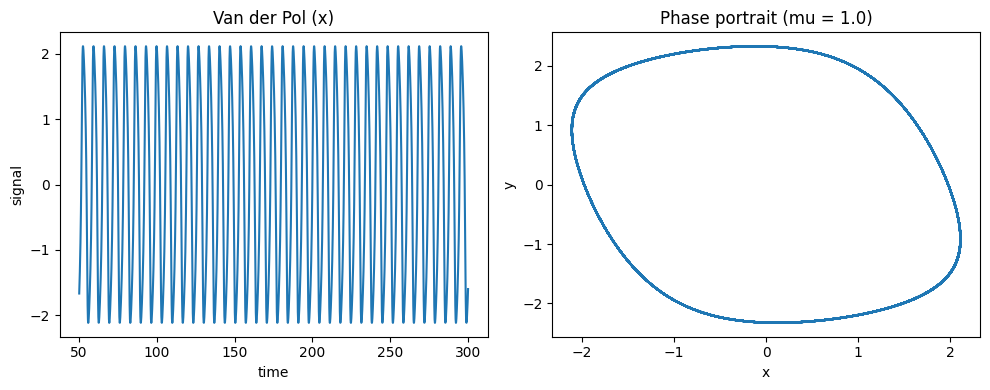

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
brainmass.viz.plot_timeseries(res['x'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Van der Pol (x)')
brainmass.viz.plot_phase_portrait(res['x'], res['y'], ax=axes[1])
axes[1].set_title('Phase portrait (mu = 1.0)')
plt.tight_layout()
plt.show()

## Try it: vary the nonlinearity `mu`

Increase `mu` to morph from near-harmonic oscillations toward stiff relaxation oscillations with sharp transitions.

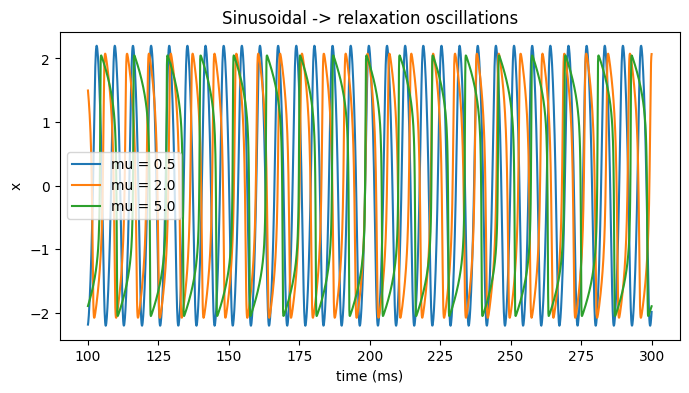

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for mu in [0.5, 2.0, 5.0]:
    m = brainmass.VanDerPolStep(in_size=1, mu=mu)
    r = brainmass.Simulator(m, dt=0.1 * u.ms).run(
        300. * u.ms, monitors=['x'], transient=100. * u.ms)
    ax.plot(u.get_magnitude(r['ts']), u.get_magnitude(r['x'])[:, 0], label=f'mu = {mu}')
ax.set_xlabel('time (ms)'); ax.set_ylabel('x'); ax.legend()
ax.set_title('Sinusoidal -> relaxation oscillations')
plt.show()